# MSI 5001 Introduction to AI: Concepts, Applications, and Evaluation (Capstone Project)

## Outlier Removal Step

- **Group:** 26
- **Members:** Alkaff, Dev, Kee Fong


## Overview

1. Convert time-series to static features by calculating statistical measures
2. Apply PCA
3. Check for outliers and remove them
4. Check for misclassification and handle them


## Identifying Outliers

1. Calculate **mean, std, median, Q1, Q3, IQR, min, max, skew, kurtosis** for each sample 
    - 10 Statistical measures
    - 120 time series features → 1200 static features
2. Build the **per-sample vector** and save the `.csv`
    - Per-sample vector contains sample name, class (output) and the 1200 features (`F0..F1199`)
3. Use `RobustScaler()` because it uses median and IQR
4. **PCA** (1200 features → 50 features) to remove noise 
5. Use **PCA-50** output, check for outliers
    - **t-SNE plots** (visual inspection)
    - **UMAP plots** (visual inspection)
    - **Isolation Forest** (per class) (programmatic)
    - **LOF** (programmatic)
6. **Remove outliers**
    - Deleting from the `mfcc`, `mel_spectro` and `wav24k` folders
    - Creating a new column `consesus` saying if the record is an outlier


## Import Statements and Setup


In [1]:
# Import Statements
# -----------------

import os
from pathlib import Path
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA

from sklearn.ensemble import IsolationForest
from sklearn.manifold import TSNE
from sklearn.neighbors import LocalOutlierFactor
import umap.umap_ as umap


In [2]:
# Global Config
# -------------

BASE_DIR = Path("D:\\MSI5001 Datasets\\Urban Sound")
RAW_TRAIN_ROOT = BASE_DIR / "raw" / "Train"
RAW_TEST_ROOT = BASE_DIR / "raw" / "Test"

MFCC_TRAIN_ROOT = BASE_DIR / "mfcc" / "Train"
MFCC_TEST_ROOT = BASE_DIR / "mfcc" / "Test"
SPECTRO_TRAIN_ROOT = BASE_DIR / "mel_spectro" / "Train"
SPECTRO_TEST_ROOT = BASE_DIR / "mel_spectro" / "Test"
WAV24_TRAIN_ROOT = BASE_DIR / "wave_24k" / "Train"
WAV24_TEST_ROOT = BASE_DIR / "wave_24k" / "Test"

MFCC_FEATS_TRAIN = BASE_DIR / "mfcc_features_train.csv"    # columns: sample (file), F0..F1199, label
MFCC_FEATS_TEST = BASE_DIR / "mfcc_features_test.csv"      # columns: sample (file), F0..F1199, label
PCA50_TRAIN = BASE_DIR / "mfcc_pca50_train.csv"    # columns: sample (file),label, PC1..PC50
PCA50_TEST = BASE_DIR / "mfcc_pca50_test.csv"      # columns: sample (file),label, PC1..PC50

SPLITS = ["Train", "Test"]


In [3]:
# Process Config
# --------------

MFCC_FEATURES = 120
STAT_FEATURES = 10

PCA_DIM = 50
RANDOM_STATE = 42

TSNE_PERPLEX   = 30
TSNE_N_ITER    = 2000

UMAP_N_NEIGH   = 15
UMAP_MIN_DIST  = 0.1

LOF_NEIGH      = 30          # try 15/30/50 if needed
CONTAMINATION  = 0.03        # 3% per class

In [4]:
# Helper Functions
# ----------------

def mfcc_stats_vector(mfcc_stack: np.ndarray) -> np.ndarray:
    """
    Input:  mfcc_stack shape (C=3*N_MFCC, T) e.g., (120, T)
    Stats per channel (over time): mean, std, median, Q1, Q3, IQR, min, max, skew, kurtosis -> 10
    Output: (C * 10,) float32 = (1200,)
    """
    if mfcc_stack.ndim != 2:
        mfcc_stack = np.atleast_2d(mfcc_stack)

    ch_mean   = mfcc_stack.mean(axis=1)
    ch_std    = mfcc_stack.std(axis=1)
    ch_median = np.median(mfcc_stack, axis=1)
    ch_q1     = np.percentile(mfcc_stack, 25, axis=1)
    ch_q3     = np.percentile(mfcc_stack, 75, axis=1)
    ch_iqr    = ch_q3 - ch_q1
    ch_min    = mfcc_stack.min(axis=1)
    ch_max    = mfcc_stack.max(axis=1)
    ch_skew   = skew(mfcc_stack, axis=1, bias=False, nan_policy="omit")
    ch_kurt   = kurtosis(mfcc_stack, axis=1, bias=False, nan_policy="omit")

    feats = np.concatenate(
        [ch_mean, ch_std, ch_median, ch_q1, ch_q3, ch_iqr, ch_min, ch_max, ch_skew, ch_kurt],
        axis=0
    ).astype(np.float32)

    feats = np.nan_to_num(feats, nan=0.0, posinf=0.0, neginf=0.0)
    return feats


def build_split_features(mfcc_root: Path, class_to_idx: dict) -> pd.DataFrame:
    """
    Walks: mfcc_root/<class>/*_mfcc.npy
    Returns a DataFrame with columns: sample, F0..F1199, label
    """
    rows = []
    feature_cols = ["F{}".format(i) for i in range(MFCC_FEATURES * STAT_FEATURES)]
    classes = sorted(class_to_idx.keys())

    for cls in classes:
        cls_dir = mfcc_root / cls
        if not cls_dir.exists():
            # skip missing class folder in this split
            continue
        for npy_path in tqdm(sorted(cls_dir.glob("*.npy")), desc="{}/*".format(cls_dir.as_posix())):
            arr = np.load(npy_path)            # (120, T)
            feats = mfcc_stats_vector(arr)     # (1200,)
            filename = npy_path.stem
            row = [filename] + feats.tolist() + [class_to_idx[cls]]
            rows.append(row)

    cols = ["sample"] + feature_cols + ["label"]
    if not rows:
        return pd.DataFrame(columns=cols)

    df = pd.DataFrame(rows, columns=cols)
    # enforce numeric dtypes
    for c in feature_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["label"] = pd.to_numeric(df["label"], downcast="integer", errors="coerce")
    return df


def per_class_counts(flag_arr, name):
    s = pd.Series(flag_arr, name=name)
    tmp = pd.concat([pd.Series(y_tr, name="label"), s], axis=1)
    return tmp.groupby("label")[name].agg(["sum","count"]).rename(columns={"sum":"flagged","count":"total"})



## Build the Per-Sample Vectors

- Train
- Test


In [5]:
# Classes to Categorical
# ----------------------

classes = sorted([d.name for d in MFCC_TRAIN_ROOT.iterdir() if d.is_dir()])
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {v: k for k, v in class_to_idx.items()}

print("Class mapping:", class_to_idx)
print("Reverse Class mapping:", idx_to_class)

Class mapping: {'air_conditioner': 0, 'car_horn': 1, 'children_playing': 2, 'dog_bark': 3, 'drilling': 4, 'engine_idling': 5, 'gun_shot': 6, 'jackhammer': 7, 'siren': 8, 'street_music': 9}
Reverse Class mapping: {0: 'air_conditioner', 1: 'car_horn', 2: 'children_playing', 3: 'dog_bark', 4: 'drilling', 5: 'engine_idling', 6: 'gun_shot', 7: 'jackhammer', 8: 'siren', 9: 'street_music'}


In [6]:
# Build the train_df and RobustScaler
# -----------------------------------

feature_cols = ["F{}".format(i) for i in range(MFCC_FEATURES * STAT_FEATURES)]
scaler = RobustScaler()

df_train = build_split_features(MFCC_TRAIN_ROOT, class_to_idx)

if len(df_train) > 0:
    Xtr = df_train[feature_cols].values.astype(np.float32)
    Xtr_s = scaler.fit_transform(Xtr).astype(np.float32)
    df_train_scaled = df_train.copy()
    df_train_scaled[feature_cols] = Xtr_s
else:
    df_train_scaled = df_train.copy()

df_train_scaled.to_csv(MFCC_FEATS_TRAIN, index=False)
print("[Saved] {}  | rows={}, cols={}".format(MFCC_FEATS_TRAIN, len(df_train_scaled), df_train_scaled.shape[1]))


D:/MSI5001 Datasets/Urban Sound/mfcc/Train/air_conditioner/*: 100%|█████████████████| 200/200 [00:00<00:00, 347.50it/s]
D:/MSI5001 Datasets/Urban Sound/mfcc/Train/car_horn/*: 100%|██████████████████████████| 78/78 [00:00<00:00, 487.94it/s]
D:/MSI5001 Datasets/Urban Sound/mfcc/Train/children_playing/*: 100%|████████████████| 200/200 [00:00<00:00, 365.32it/s]
D:/MSI5001 Datasets/Urban Sound/mfcc/Train/dog_bark/*: 100%|████████████████████████| 200/200 [00:00<00:00, 387.42it/s]
D:/MSI5001 Datasets/Urban Sound/mfcc/Train/drilling/*: 100%|████████████████████████| 200/200 [00:00<00:00, 389.11it/s]
D:/MSI5001 Datasets/Urban Sound/mfcc/Train/engine_idling/*: 100%|███████████████████| 196/196 [00:00<00:00, 340.91it/s]
D:/MSI5001 Datasets/Urban Sound/mfcc/Train/gun_shot/*: 100%|██████████████████████████| 70/70 [00:00<00:00, 476.20it/s]
D:/MSI5001 Datasets/Urban Sound/mfcc/Train/jackhammer/*: 100%|██████████████████████| 239/239 [00:00<00:00, 311.35it/s]
D:/MSI5001 Datasets/Urban Sound/mfcc/Tra

[Saved] D:\MSI5001 Datasets\Urban Sound\mfcc_features_train.csv  | rows=1760, cols=1202


In [7]:
# Build the test_df and use the scaler
# ------------------------------------

df_test = build_split_features(MFCC_TEST_ROOT, class_to_idx)

if len(df_test) > 0 and len(df_train) > 0:
    Xte = df_test[feature_cols].values.astype(np.float32)
    Xte_s = scaler.transform(Xte).astype(np.float32)
    df_test_scaled = df_test.copy()
    df_test_scaled[feature_cols] = Xte_s
else:
    df_test_scaled = df_test.copy()

df_test_scaled.to_csv(MFCC_FEATS_TEST, index=False)
print("[Saved] {}  | rows={}, cols={}".format(MFCC_FEATS_TEST, len(df_test_scaled), df_test_scaled.shape[1]))


D:/MSI5001 Datasets/Urban Sound/mfcc/Test/air_conditioner/*: 100%|██████████████████| 100/100 [00:00<00:00, 343.64it/s]
D:/MSI5001 Datasets/Urban Sound/mfcc/Test/car_horn/*: 100%|███████████████████████████| 33/33 [00:00<00:00, 423.07it/s]
D:/MSI5001 Datasets/Urban Sound/mfcc/Test/children_playing/*: 100%|█████████████████| 100/100 [00:00<00:00, 353.41it/s]
D:/MSI5001 Datasets/Urban Sound/mfcc/Test/dog_bark/*: 100%|█████████████████████████| 100/100 [00:00<00:00, 389.10it/s]
D:/MSI5001 Datasets/Urban Sound/mfcc/Test/drilling/*: 100%|█████████████████████████| 100/100 [00:00<00:00, 381.68it/s]
D:/MSI5001 Datasets/Urban Sound/mfcc/Test/engine_idling/*: 100%|██████████████████████| 93/93 [00:00<00:00, 353.62it/s]
D:/MSI5001 Datasets/Urban Sound/mfcc/Test/gun_shot/*: 100%|███████████████████████████| 32/32 [00:00<00:00, 499.95it/s]
D:/MSI5001 Datasets/Urban Sound/mfcc/Test/jackhammer/*: 100%|█████████████████████████| 96/96 [00:00<00:00, 253.97it/s]
D:/MSI5001 Datasets/Urban Sound/mfcc/Tes

[Saved] D:\MSI5001 Datasets\Urban Sound\mfcc_features_test.csv  | rows=837, cols=1202


## Generate PCA

- Removes noise
- Fit PCA on Train, then Transform on both Train and Test


In [8]:
# PCA Setup
# ---------

pca = PCA(n_components=PCA_DIM, whiten=True, random_state=42)

# Fit on TRAIN only
Xtr_pca = pca.fit_transform(Xtr_s)
Xte_pca = pca.transform(Xte_s) if Xte.shape[0] else Xte_s

print("PCA dims:", Xtr_pca.shape[1], "| variance retained (sum):", pca.explained_variance_ratio_.sum())


PCA dims: 50 | variance retained (sum): 0.83852494


### Observations: 

- Variance retained = `83.9%`
- This means the remaining 16.1% was lost
- We can assume the loss is noise


In [9]:
# Build PCA
# ---------

# Build PCA dataframes, keep sample + label columns for traceability
train_pca_cols = [f"PC{i+1}" for i in range(Xtr_pca.shape[1])]
df_train_pca = pd.concat(
    [df_train_scaled[["sample", "label"]].reset_index(drop=True),
     pd.DataFrame(Xtr_pca, columns=train_pca_cols)],
    axis=1
)

df_test_pca = pd.concat(
    [df_test_scaled[["sample", "label"]].reset_index(drop=True),
     pd.DataFrame(Xte_pca, columns=train_pca_cols)],
    axis=1
) if len(df_test_scaled) else pd.DataFrame(columns=["sample","label"] + train_pca_cols)

# Save to csv
df_train_pca.to_csv(PCA50_TRAIN, index=False)
df_test_pca.to_csv(PCA50_TEST, index=False)
print(f"[Saved] {PCA50_TRAIN} \n[Saved] {PCA50_TEST}")


[Saved] D:\MSI5001 Datasets\Urban Sound\mfcc_pca50_train.csv 
[Saved] D:\MSI5001 Datasets\Urban Sound\mfcc_pca50_test.csv


## Outlier Analysis

1. t-SNE
2. UMAP
3. Isolation Forest (per-class)
4. LOF (per-class)
5. Process the results


In [10]:
# Load the PCA-50
# ---------------

df_tr = pd.read_csv(PCA50_TRAIN)
pc_cols = [c for c in df_tr.columns if c.startswith("PC")]

df_tr.head()


,sample,label,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,...,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
0,Train_1000__air_conditioner,0,-0.304915,-0.495137,0.170468,0.108353,-0.128957,0.072862,-0.194894,-0.375161,...,-0.185866,-0.264625,0.252698,0.216851,0.143318,-0.149825,0.452906,0.552876,-0.128209,-0.157374
1,Train_1001__air_conditioner,0,-0.316500,-0.636343,0.342823,0.114430,-0.057138,0.169725,-0.086054,-0.481152,...,-0.239943,0.990454,-0.106343,0.138009,0.407059,-0.221921,-0.456415,0.268811,0.406094,0.145812
2,Train_1002__air_conditioner,0,-0.290270,-0.625031,0.276710,0.074308,-0.027264,0.145390,-0.017224,-0.509620,...,-0.031775,0.077958,0.027641,0.260585,0.579585,-0.058270,0.072258,0.173930,0.192569,-0.431906
3,Train_1003__air_conditioner,0,-0.286249,-0.620660,0.265344,0.023410,-0.023004,0.029641,-0.091810,-0.369755,...,-0.461212,-0.123399,0.197410,-0.375877,0.310611,0.569711,0.140598,0.292913,-0.101787,-0.161200
4,Train_1004__air_conditioner,0,-0.290277,-0.639737,0.319492,0.093101,-0.016827,0.094574,-0.121799,-0.444536,...,-0.386036,0.231275,-0.378653,0.071092,0.088904,-0.100095,0.064997,-0.042853,0.282234,-0.479731


In [11]:
X_tr = df_tr[pc_cols].values.astype(np.float32)
y_tr = df_tr["label"].values
samples_tr = df_tr["sample"].astype(str).values

classes = np.unique(y_tr)
print(f"[INFO] Train shapes: X={X_tr.shape}, classes={len(classes)}, PCs={len(pc_cols)}")

res = df_tr[["sample", "label"]].copy()

[INFO] Train shapes: X=(1760, 50), classes=10, PCs=50


### t-SNE

In [12]:
# t-SNE Train and Store Results
# -----------------------------

tsne = TSNE(
    n_components=2,
    perplexity=TSNE_PERPLEX,
    learning_rate="auto",
    n_iter=TSNE_N_ITER,
    init="pca",
    random_state=RANDOM_STATE,
    verbose=1
)

X_tsne = tsne.fit_transform(X_tr)
res["tsne_x"], res["tsne_y"] = X_tsne[:,0], X_tsne[:,1]
print(X_tsne)


C:\Users\Alkaff\anaconda3\envs\tf\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\Alkaff\anaconda3\envs\tf\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Alkaff\anaconda3\envs\tf\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\Alkaff\anaconda3\envs\tf\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\Alkaff\anaconda3\envs\tf\lib\subprocess.py", line 951, in __init__
    self._execute_child(a

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1760 samples in 0.000s...
[t-SNE] Computed neighbors for 1760 samples in 0.174s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1760
[t-SNE] Computed conditional probabilities for sample 1760 / 1760
[t-SNE] Mean sigma: 1.118581
[t-SNE] KL divergence after 250 iterations with early exaggeration: 73.851700
[t-SNE] KL divergence after 2000 iterations: 1.163995
[[-14.142826   -4.5248957]
 [-22.157757  -17.714361 ]
 [-16.112535    1.0388013]
 ...
 [  0.3387959  -1.0140061]
 [  4.5972824  -3.4819577]
 [  1.706893   -1.5875856]]


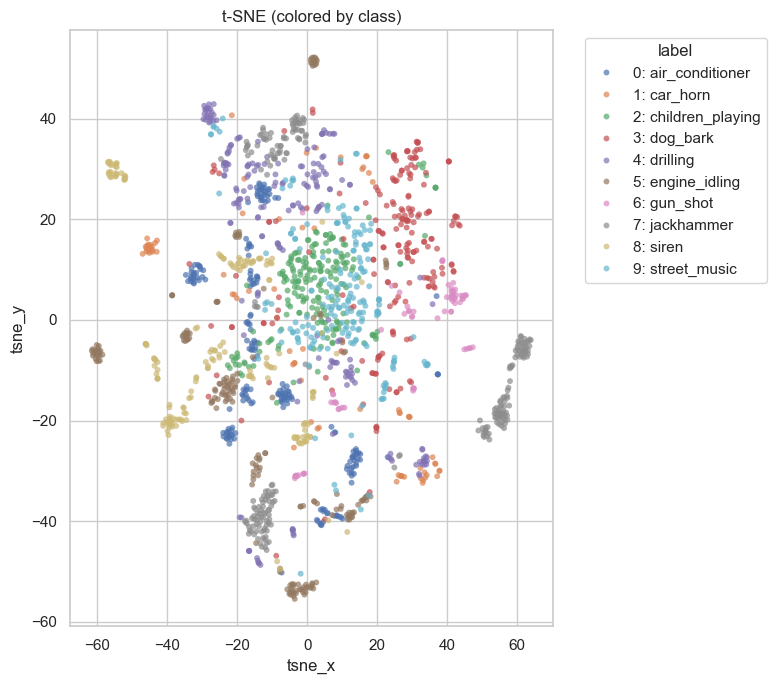

In [13]:
# Plot t-SNE (colored by class)
# -----------------------------

# Attach classnames for better looks
res["label_pretty"] = res["label"].apply(
    lambda i: f"{i}: {idx_to_class.get(i, 'UNKNOWN')}"
)
hue_order = [f"{i}: {idx_to_class.get(i, 'UNKNOWN')}" for i in sorted(idx_to_class.keys())]

# Plot Settings
sns.set(context="notebook", style="whitegrid")
plt.figure(figsize=(8,7))

# Plot
sns.scatterplot(x=res["tsne_x"], 
                y=res["tsne_y"], 
                hue=res["label_pretty"], 
                hue_order=hue_order, 
                s=18, 
                alpha=0.7, 
                linewidth=0)

plt.title("t-SNE (colored by class)")
plt.legend(title="label", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.savefig("02a_tsne_coloured.png")
plt.show()


### UMAP

- `cosine` distance is preferred because it looks at the similarity in direction of the vectors
- Our data has 50 dimensions (very high), so its more suitable to use `cosine` distance instead of `euclidean` which is absolute distance
- Case study: Embedding vectors use `cosine` distance because it looks for "similarity in direction" instead of "absolute distance". Our case is similar to Embedding vector case


In [14]:
# UMAP Train and Store Results
# ----------------------------

um = umap.UMAP(
    n_components=2,
    n_neighbors=UMAP_N_NEIGH,
    min_dist=UMAP_MIN_DIST,
    metric="cosine",      # 'cosine' also works well on PCA-whitened features euclidean
    random_state=RANDOM_STATE
)

X_umap = um.fit_transform(X_tr)
res["umap_x"], res["umap_y"] = X_umap[:,0], X_umap[:,1]
print(X_umap)


C:\Users\Alkaff\anaconda3\envs\tf\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[[13.377837    0.02542331]
 [ 9.770934    7.1909876 ]
 [13.760114    0.28056914]
 ...
 [13.395694    0.43909466]
 [11.924968    2.639651  ]
 [12.402045    2.2767222 ]]


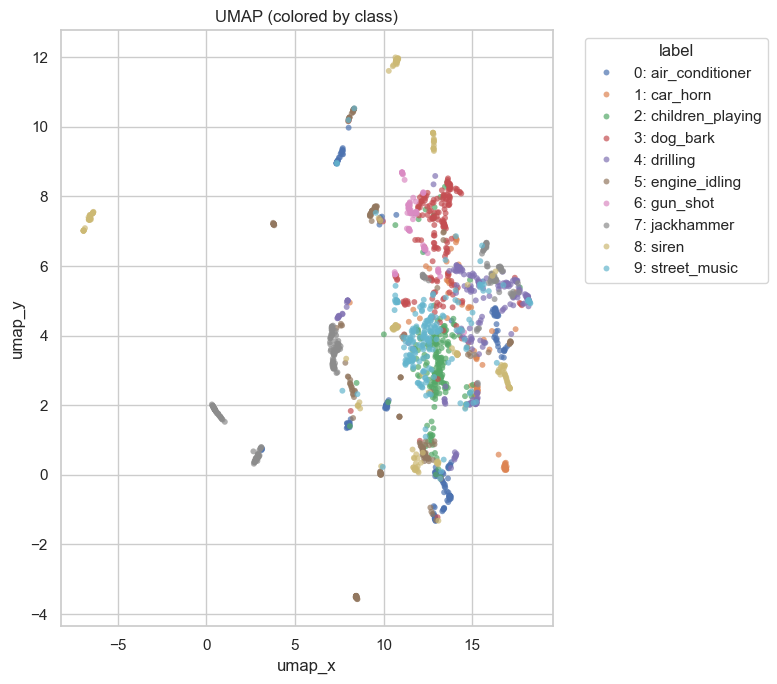

In [15]:
# Plot UMAP (colored by class)
# ----------------------------

plt.figure(figsize=(8,7))

sns.scatterplot(x=res["umap_x"], 
                y=res["umap_y"], 
                hue=res["label_pretty"], 
                hue_order=hue_order, 
                s=18, 
                alpha=0.7, 
                linewidth=0)

plt.title("UMAP (colored by class)")
plt.legend(title="label", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.savefig("02b_umap_coloured.png")
plt.show()

### Observations:

- **t-SNE** shows groups overlapping (e.g. children playing and street music)
    - This means the model may possibly misclassify children playing and street music
- **t-SNE** shows some classes exist in multiple islands (e.g. Siren, Jackhammer)
    - This means the specific classes may have sub variants or more than 1 unique sounds
- **UMAP** with cosine distance shows the MFCC features regardless of loudness
- Most points in **UMAP** are clustered to the center → most classes genuinely have similar MFCC features


### Isolation Forest

In [16]:
# Isolation Forest (per-class)
# ----------------------------

if_scores = np.zeros(len(df_tr), dtype=np.float32)
if_flags  = np.zeros(len(df_tr), dtype=bool)

for cls in classes:
    mask = (y_tr == cls)
    Xc = X_tr[mask]
    if Xc.shape[0] < 10:
        print(f"[IF][WARN] Class {cls} has only {Xc.shape[0]} samples; skipping.")
        continue
    iso = IsolationForest(
        n_estimators=200,
        contamination=CONTAMINATION,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    iso.fit(Xc)
    d = iso.decision_function(Xc)  # higher = more normal
    if_scores[mask] = (-d).astype(np.float32)   # higher = more anomalous
    if_flags[mask]  = (iso.predict(Xc) == -1)

res["if_score"],  res["if_flag"]  = if_scores, if_flags
print(f"[IF] Total flagged: {if_flags.sum()} ({100*if_flags.mean():.2f}%)")


[IF] Total flagged: 56 (3.18%)


### LOF

In [17]:
# ---------- LOF (per-class) ----------
# Note: Using default novelty=False → fit_predict on TRAIN only (this is fine for train-set cleaning).
lof_scores = np.zeros(len(df_tr), dtype=np.float32)
lof_flags  = np.zeros(len(df_tr), dtype=bool)

for cls in classes:
    mask = (y_tr == cls)
    Xc = X_tr[mask]
    if Xc.shape[0] <= LOF_NEIGH:
        print(f"[LOF][WARN] Class {cls} has {Xc.shape[0]} samples; reduce LOF_NEIGH or skip.")
        continue

    lof = LocalOutlierFactor(
        n_neighbors=LOF_NEIGH,
        contamination=CONTAMINATION,
        metric="euclidean",
        novelty=False
    )
    pred = lof.fit_predict(Xc)  # -1 = outlier, 1 = inlier
    # negative_outlier_factor_: more negative => more outlier
    sc = -lof.negative_outlier_factor_.astype(np.float32)  # higher = more anomalous

    lof_flags[mask]  = (pred == -1)
    lof_scores[mask] = sc

res["lof_score"], res["lof_flag"] = lof_scores, lof_flags
print(f"[LOF] Total flagged: {lof_flags.sum()} ({100*lof_flags.mean():.2f}%)")


[LOF] Total flagged: 56 (3.18%)


### Process Results


In [18]:
# Consolidate Results
# -------------------

res["consensus_flag"] = res["if_flag"] & res["lof_flag"]  # conservative: flagged by both
res.to_csv(BASE_DIR / "outlier_scores_train.csv", index=False)
print("Saved → " + str(BASE_DIR / "outlier_scores_train.csv"))

Saved → D:\MSI5001 Datasets\Urban Sound\outlier_scores_train.csv


In [19]:
# Redo to Add Classname Column
# ----------------------------

def per_class_counts(flag_arr, name):
    s = pd.Series(flag_arr, name=name)

    # y_tr is your ground-truth class index per sample (0..9)
    tmp = pd.concat([pd.Series(y_tr, name="label"), s], axis=1)

    # group per label: how many were flagged, and how many total
    df = (
        tmp.groupby("label")[name]
          .agg(["sum", "count"])
          .rename(columns={"sum": "flagged", "count": "total"})
          .reset_index()  # bring 'label' out of the index
    )

    # add human-readable class name next to the numeric label
    df["class_name"] = df["label"].map(idx_to_class).fillna("UNKNOWN")

    # reorder columns: label | class_name | flagged | total
    df = df[["label", "class_name", "flagged", "total"]]

    return df


In [20]:
# Metrics
# -------

sum_if   = per_class_counts(if_flags, "if_flag")
sum_lof  = per_class_counts(lof_flags, "lof_flag")
sum_cons = per_class_counts(res["consensus_flag"].values, "consensus_flag")

print("\n[Per-class IF] flagged / total:")
display(sum_if.assign(pct=lambda d: 100*d.flagged/d.total))

print("\n[Per-class LOF] flagged / total:")
display(sum_lof.assign(pct=lambda d: 100*d.flagged/d.total))

print("\n[Per-class CONSENSUS (IF ∩ LOF)] flagged / total:")
display(sum_cons.assign(pct=lambda d: 100*d.flagged/d.total))



[Per-class IF] flagged / total:


,label,class_name,flagged,total,pct
0,0,air_conditioner,6,200,3.000000
1,1,car_horn,3,78,3.846154
2,2,children_playing,6,200,3.000000
3,3,dog_bark,6,200,3.000000
4,4,drilling,6,200,3.000000
5,5,engine_idling,6,196,3.061224
6,6,gun_shot,3,70,4.285714
7,7,jackhammer,8,239,3.347280
8,8,siren,6,177,3.389831
9,9,street_music,6,200,3.000000



[Per-class LOF] flagged / total:


,label,class_name,flagged,total,pct
0,0,air_conditioner,6,200,3.000000
1,1,car_horn,3,78,3.846154
2,2,children_playing,6,200,3.000000
3,3,dog_bark,6,200,3.000000
4,4,drilling,6,200,3.000000
5,5,engine_idling,6,196,3.061224
6,6,gun_shot,3,70,4.285714
7,7,jackhammer,8,239,3.347280
8,8,siren,6,177,3.389831
9,9,street_music,6,200,3.000000



[Per-class CONSENSUS (IF ∩ LOF)] flagged / total:


,label,class_name,flagged,total,pct
0,0,air_conditioner,4,200,2.000000
1,1,car_horn,0,78,0.000000
2,2,children_playing,5,200,2.500000
3,3,dog_bark,5,200,2.500000
4,4,drilling,3,200,1.500000
5,5,engine_idling,6,196,3.061224
6,6,gun_shot,3,70,4.285714
7,7,jackhammer,3,239,1.255230
8,8,siren,5,177,2.824859
9,9,street_music,5,200,2.500000


In [21]:

agree = ((if_flags == lof_flags).mean())
both  = (if_flags & lof_flags).mean()
either= (if_flags | lof_flags).mean()
print(f"\n[Agreement] IF vs LOF → agree={agree:.3f}, both={both:.3f}, either={either:.3f}")



[Agreement] IF vs LOF → agree=0.981, both=0.022, either=0.041


**What these means:**

- Both IF and LOF makes the **same judgement** `98.1%` of the time
- If **both** IF and LOF **agreed** on an outlier (IF ∩ LOF), there are `2.2%` outliers (conservative) ← we are going with this
- If **either** IF or LOF **agreed** on an outlier (IF ∪ LOF), there are `4.1%` outliers (aggresive)

We decided to take the **conservative** approach because
- Our dataset is limited - we cannot afford to lose too much data


### Plotting t-SNE and UMAP with Outliers Marked


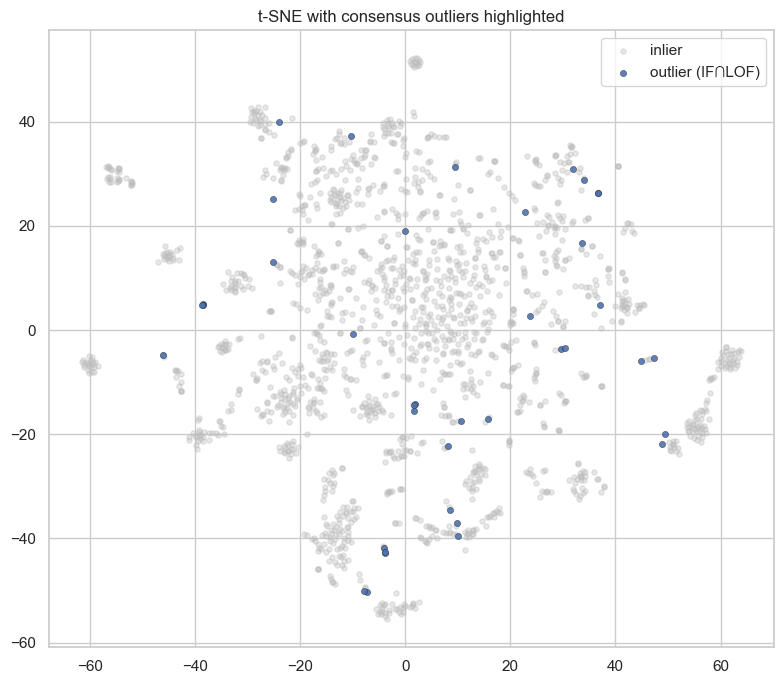

In [22]:
# Plot t-SNE with outliers
# ------------------------

plt.figure(figsize=(8,7))
inliers  = ~res["consensus_flag"].values
outliers =  res["consensus_flag"].values

plt.scatter(res.loc[inliers,"tsne_x"],  res.loc[inliers,"tsne_y"],  s=14, alpha=0.35, label="inlier", c="#bbbbbb")
plt.scatter(res.loc[outliers,"tsne_x"], res.loc[outliers,"tsne_y"], s=20, alpha=0.9,  label="outlier (IF∩LOF)", edgecolor="k", linewidths=0.3)

plt.title("t-SNE with consensus outliers highlighted")
plt.legend()
plt.tight_layout()

plt.savefig("02c_tsne_outliers.png")
plt.show()

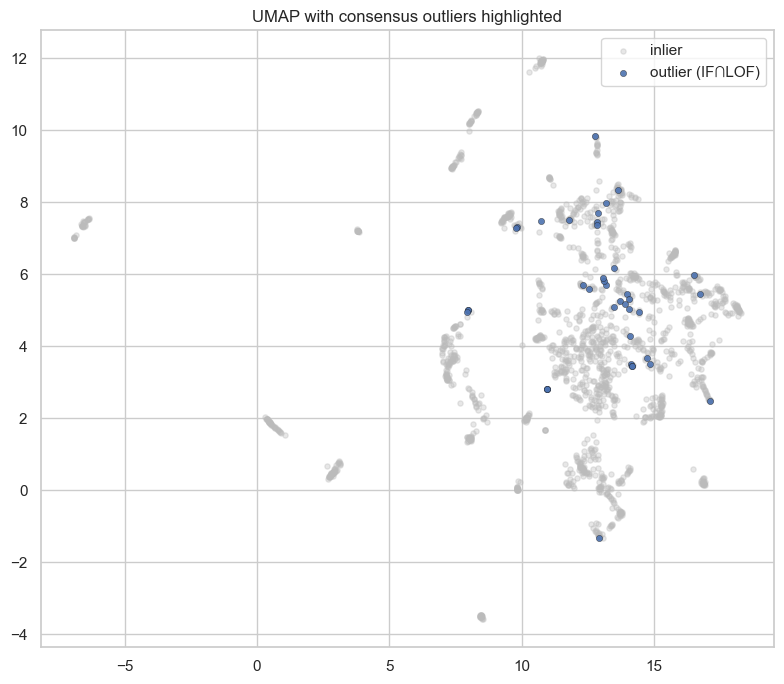

In [23]:
# Plot UMAP with outliers
# -----------------------

plt.figure(figsize=(8,7))

plt.scatter(res.loc[inliers,"umap_x"],  res.loc[inliers,"umap_y"],  s=14, alpha=0.35, label="inlier", c="#bbbbbb")
plt.scatter(res.loc[outliers,"umap_x"], res.loc[outliers,"umap_y"], s=20, alpha=0.9,  label="outlier (IF∩LOF)", edgecolor="k", linewidths=0.3)

plt.title("UMAP with consensus outliers highlighted")
plt.legend()
plt.tight_layout()

plt.savefig("02d_umap_outliers.png")
plt.show()

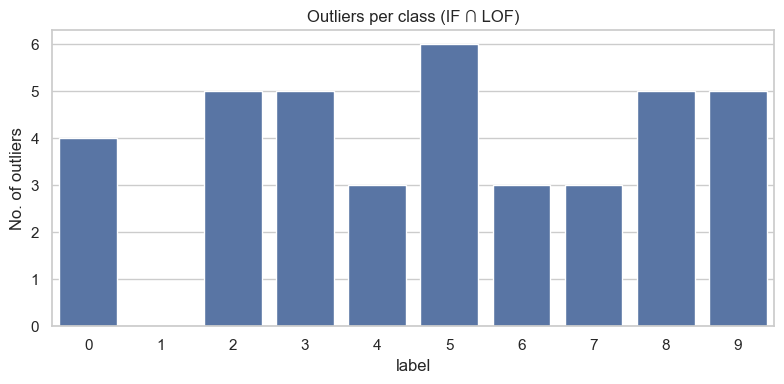

In [24]:
# Per-class bar: number of outliers (consensus)
# ---------------------------------------------

plt.figure(figsize=(8,4))
bar = res.groupby("label")["consensus_flag"].sum()

sns.barplot(x=bar.index.astype(str), y=bar.values)

plt.xlabel("label"); plt.ylabel("No. of outliers")
plt.title("Outliers per class (IF ∩ LOF)")
plt.tight_layout()

plt.savefig("02e_outliers_per_class.png")
plt.show()

## Remove Outliers


In [28]:
# Load CSV
# --------

df_remove_outlier = pd.read_csv(BASE_DIR / "outlier_scores_train.csv")
print(df_remove_outlier.dtypes)


sample             object
label               int64
tsne_x            float64
tsne_y            float64
label_pretty       object
umap_x            float64
umap_y            float64
if_score          float64
if_flag              bool
lof_score         float64
lof_flag             bool
consensus_flag       bool
dtype: object


In [29]:
# Create the Remove List
# ----------------------

df_remove_files = df_remove_outlier.loc[
    df_remove_outlier["consensus_flag"],
    ["sample", "label"]
]

print(f"[INFO ] {len(to_remove)} samples flagged for removal")


[INFO ] 39 samples flagged for removal


In [31]:
# Remove Files
# ------------

for row in tqdm(df_remove_files.itertuples(index=False), desc="Removing samples"):
    stem = str(row.sample)
    label_idx = row.label
    class_name = idx_to_class.get(label_idx, "UNKNOWN")

    spectro_path = SPECTRO_TRAIN_ROOT / class_name / f"{stem}.png"
    mfcc_path = MFCC_TRAIN_ROOT / class_name / f"{stem}.npy"
    wav24_path = WAV24_TRAIN_ROOT / class_name / f"{stem}.wav"

    for p in [spectro_path, mfcc_path, wav24_path]:
        if p.exists():
            try:
                os.remove(p)
            except Exception as e:
                print(f"[ERROR ] Could not delete {p}: {e}")
        else:
            print(f"[MISS  ] {p} (not found)")

print("\n[DONE ] Cleanup complete.")

Removing samples: 39it [00:00, 2601.68it/s]


[DONE ] Cleanup complete.


In [32]:
# Load DF
# -------

train_mfcc_df = pd.read_csv(MFCC_FEATS_TRAIN)
train_pca_df = pd.read_csv(PCA50_TRAIN)


In [33]:
# Remove Rows
# -----------

# Filter out outliers where consensus_flag == True
to_remove = df_remove_outlier.loc[df_remove_outlier["consensus_flag"] == True, "sample"]

# Remove matching samples from both training DataFrames
train_mfcc_df_clean = train_mfcc_df[~train_mfcc_df["sample"].isin(to_remove)].reset_index(drop=True)
train_pca_df_clean = train_pca_df[~train_pca_df["sample"].isin(to_remove)].reset_index(drop=True)

print(f"Original MFCC train size: {len(train_mfcc_df)}, after cleaning: {len(train_mfcc_df_clean)}")
print(f"Original PCA train size:  {len(train_pca_df)}, after cleaning:  {len(train_pca_df_clean)}")
print(f"Removed {len(to_remove)} outlier samples based on consensus flag.")

# Save cleaned versions
train_mfcc_df_clean.to_csv(BASE_DIR / "mfcc_features_train_clean.csv", index=False)
train_pca_df_clean.to_csv(BASE_DIR / "mfcc_pca50_train_clean.csv", index=False)

print("\n[DONE ] Cleanup complete.")


Original MFCC train size: 1760, after cleaning: 1721
Original PCA train size:  1760, after cleaning:  1721
Removed 39 outlier samples based on consensus flag.

[DONE ] Cleanup complete.
